# US Pumpkins

Predict the price of a pumpkin for sale during a given month

In [141]:
import pandas as pd

df = pd.read_csv('data/US-pumpkins.csv')
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [142]:
df.shape

(1757, 26)

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   object 
 1   Type             45 non-null     object 
 2   Package          1757 non-null   object 
 3   Variety          1752 non-null   object 
 4   Sub Variety      296 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   object 
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   object 
 12  Origin District  131 non-null    object 
 13  Item Size        1478 non-null   object 
 14  Color            1141 non-null   object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    object 
 17  Quality       

- 1757 righe
- ci sono colonne totalmente vuote
- ci sono colonne "unnamed"

## Pulizia

In [144]:
columns_to_keep = ['City Name', 'Package', 'Variety', 'Date', 'Low Price', 'High Price', 'Origin', 'Item Size', 'Repack']
df_cleaned = df[columns_to_keep].copy()
df_cleaned

,City Name,Package,Variety,Date,Low Price,High Price,Origin,Item Size,Repack
0,BALTIMORE,24 inch bins,NaN,4/29/17,270.00,280.00,MARYLAND,lge,E
1,BALTIMORE,24 inch bins,NaN,5/6/17,270.00,280.00,MARYLAND,lge,E
2,BALTIMORE,24 inch bins,HOWDEN TYPE,9/24/16,160.00,160.00,DELAWARE,med,N
3,BALTIMORE,24 inch bins,HOWDEN TYPE,9/24/16,160.00,160.00,VIRGINIA,med,N
4,BALTIMORE,24 inch bins,HOWDEN TYPE,11/5/16,90.00,100.00,MARYLAND,lge,N
...,...,...,...,...,...,...,...,...,...
1752,ST. LOUIS,22 lb cartons,MINIATURE,9/30/16,14.75,14.75,ILLINOIS,NaN,N
1753,ST. LOUIS,36 inch bins,MINIATURE,9/26/16,275.00,275.00,MICHIGAN,sml,N
1754,ST. LOUIS,36 inch bins,MINIATURE,9/27/16,275.00,275.00,MICHIGAN,sml,N
1755,ST. LOUIS,36 inch bins,MINIATURE,9/28/16,275.00,275.00,MICHIGAN,sml,N


In [145]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City Name   1757 non-null   object 
 1   Package     1757 non-null   object 
 2   Variety     1752 non-null   object 
 3   Date        1757 non-null   object 
 4   Low Price   1757 non-null   float64
 5   High Price  1757 non-null   float64
 6   Origin      1754 non-null   object 
 7   Item Size   1478 non-null   object 
 8   Repack      1757 non-null   object 
dtypes: float64(2), object(7)
memory usage: 123.7+ KB


ci sono valori null ancora in Variety, Item Size e Origin

In [146]:
df_cleaned['Variety'].value_counts(dropna=False)

Variety
HOWDEN TYPE                 542
PIE TYPE                    468
MINIATURE                   310
FAIRYTALE                   132
CINDERELLA                   81
BIG MACK TYPE                74
MIXED HEIRLOOM VARIETIES     57
HOWDEN WHITE TYPE            49
KNUCKLE HEAD                 20
BLUE TYPE                    19
NaN                           5
Name: count, dtype: int64

In [147]:
# rimuoviamo le righe con valori null in Variety
df_cleaned = df_cleaned.dropna(subset=['Variety'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1752 entries, 2 to 1756
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City Name   1752 non-null   object 
 1   Package     1752 non-null   object 
 2   Variety     1752 non-null   object 
 3   Date        1752 non-null   object 
 4   Low Price   1752 non-null   float64
 5   High Price  1752 non-null   float64
 6   Origin      1749 non-null   object 
 7   Item Size   1473 non-null   object 
 8   Repack      1752 non-null   object 
dtypes: float64(2), object(7)
memory usage: 136.9+ KB


In [148]:
df_cleaned['Origin'].value_counts(dropna=False)

Origin
PENNSYLVANIA      250
MICHIGAN          237
CALIFORNIA        218
MASSACHUSETTS     197
ILLINOIS          156
TEXAS             112
OHIO              111
CANADA             86
MARYLAND           81
NORTH CAROLINA     67
VIRGINIA           65
MEXICO             45
NEW JERSEY         33
NEW YORK           26
DELAWARE           18
MISSOURI           11
WASHINGTON         10
INDIANA             6
VERMONT             6
ALABAMA             4
NaN                 3
NEW MEXICO          3
COSTA RICA          3
FLORIDA             2
TENNESSEE           2
Name: count, dtype: int64

In [149]:
df_cleaned['Item Size'].value_counts(dropna=False)

Item Size
sml        363
med        337
lge        290
NaN        279
xlge       205
med-lge    133
jbo        128
exjbo       17
Name: count, dtype: int64

In [150]:
# c'è correlazione tra Item Size e Package?
pd.crosstab(df_cleaned['Item Size'], df_cleaned['Package'], dropna=False)

Package,1 1/9 bushel cartons,1 1/9 bushel crates,1/2 bushel cartons,20 lb cartons,22 lb cartons,24 inch bins,35 lb cartons,36 inch bins,40 lb cartons,50 lb cartons,50 lb sacks,bins,bushel baskets,bushel cartons,each
Item Size,,,,,,,,,,,,,,,
exjbo,0,0,0,0,0,0,0,12,0,0,0,0,0,0,5
jbo,0,0,0,0,0,50,0,78,0,0,0,0,0,0,0
lge,0,0,0,6,0,74,0,191,0,0,7,2,0,5,5
med,82,3,0,0,0,132,0,108,0,7,2,1,0,2,0
med-lge,0,0,0,0,0,41,0,84,0,0,0,0,0,8,0
sml,26,14,148,0,0,85,0,70,0,0,0,2,0,13,5
xlge,0,0,0,0,0,97,0,100,0,0,0,8,0,0,0
NaN,9,0,86,0,10,67,42,20,19,3,2,0,10,9,2


Togliamo anche Item Size. Non sappiamo come riempire i valori vuoti.

City Name e Origin non ci serviranno più.

In [151]:
df_cleaned = df_cleaned.drop(columns=['Item Size', 'City Name', 'Origin'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1752 entries, 2 to 1756
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Package     1752 non-null   object 
 1   Variety     1752 non-null   object 
 2   Date        1752 non-null   object 
 3   Low Price   1752 non-null   float64
 4   High Price  1752 non-null   float64
 5   Repack      1752 non-null   object 
dtypes: float64(2), object(4)
memory usage: 95.8+ KB


In [152]:
df_cleaned['Repack'].value_counts()  

Repack
N    1749
E       3
Name: count, dtype: int64

In [153]:
df_cleaned = df_cleaned.drop(columns=['Repack']) # non ci serve più

In Package ci sono tante dimensioni che non possiamo uniformare.

Scegliamo solo le righe con "inch bins" nel valore.

Dobbiamo ancora sistemare la data, tirando fuori solo il mese, e facciamo una colonna col prezzo medio.

In [154]:
package_to_keep = ['24 inch bins', '36 inch bins']
df_cleaned = df_cleaned[df_cleaned['Package'].isin(package_to_keep)]

In [155]:
df_cleaned['Avg Price'] = (df_cleaned['Low Price'] + df_cleaned['High Price']) / 2

In [156]:
df_cleaned

,Package,Variety,Date,Low Price,High Price,Avg Price
2,24 inch bins,HOWDEN TYPE,9/24/16,160.0,160.0,160.0
3,24 inch bins,HOWDEN TYPE,9/24/16,160.0,160.0,160.0
4,24 inch bins,HOWDEN TYPE,11/5/16,90.0,100.0,95.0
5,24 inch bins,HOWDEN TYPE,11/12/16,90.0,100.0,95.0
6,36 inch bins,HOWDEN TYPE,9/24/16,160.0,170.0,165.0
...,...,...,...,...,...,...
1718,24 inch bins,MIXED HEIRLOOM VARIETIES,9/30/16,135.0,135.0,135.0
1753,36 inch bins,MINIATURE,9/26/16,275.0,275.0,275.0
1754,36 inch bins,MINIATURE,9/27/16,275.0,275.0,275.0
1755,36 inch bins,MINIATURE,9/28/16,275.0,275.0,275.0


In [157]:
# gestiamo il prezzo per unità di peso/volume in Package


def get_unit(package):
    if '24 inch bins' in package:
        return 24
    elif '36 inch bins' in package:
        return 36
    else:
        return None
    
unit = df_cleaned['Package'].apply(get_unit)
df_cleaned['Unit Price'] = df_cleaned['Avg Price'] / unit

In [158]:
months = pd.DatetimeIndex(df_cleaned['Date']).month

In [159]:
df_pumpkins = pd.DataFrame({
    'Month': months,
    'Variety': df_cleaned['Variety'],
    'Avg Price': df_cleaned['Avg Price'],
    'Unit Price': df_cleaned['Unit Price'],
    'Low Price': df_cleaned['Low Price'],
    'High Price': df_cleaned['High Price'],
    'Package': df_cleaned['Package']
})
df_pumpkins.to_csv('data/US-pumpkins-cleaned.csv', index=False)

## Analisi

In [160]:
df_pumpkins = pd.read_csv('data/US-pumpkins-cleaned.csv')

In [161]:
df_pumpkins.describe(include='all')

,Month,Variety,Avg Price,Unit Price,Low Price,High Price,Package
count,1209.000000,1209,1209.000000,1209.000000,1209.000000,1209.000000,1209
unique,NaN,10,NaN,NaN,NaN,NaN,2
top,NaN,HOWDEN TYPE,NaN,NaN,NaN,NaN,36 inch bins
freq,NaN,537,NaN,NaN,NaN,NaN,663
mean,9.569892,NaN,174.385765,5.930519,168.611530,180.160000,NaN
std,1.153150,NaN,59.297611,2.470065,58.026127,61.681255,NaN
min,1.000000,NaN,0.240000,0.008333,0.240000,0.240000,NaN
25%,9.000000,NaN,140.000000,4.166667,140.000000,145.000000,NaN
50%,10.000000,NaN,170.000000,5.555556,160.000000,170.000000,NaN
75%,10.000000,NaN,200.000000,7.083333,200.000000,215.000000,NaN


In [162]:
import seaborn as sns

[Text(0.5, 1.0, 'Distribution of Pumpkin Prices per Unit (24/36 inch bins)')]

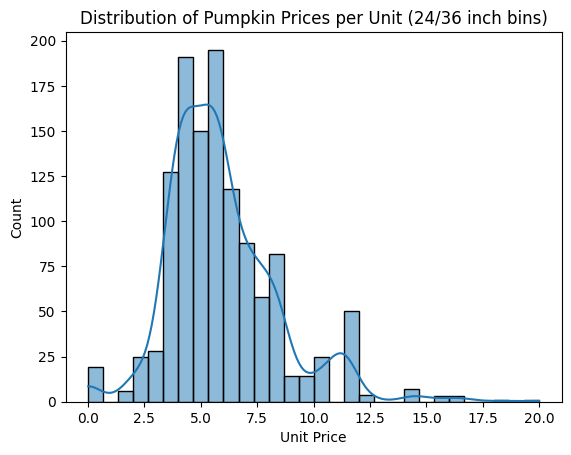

In [163]:
plot = sns.histplot(data=df_pumpkins, x='Unit Price', bins=30, kde=True)
plot.set(title='Distribution of Pumpkin Prices per Unit (24/36 inch bins)')

<Axes: title={'center': 'Number of Pumpkin Sales by Month'}, xlabel='Month'>

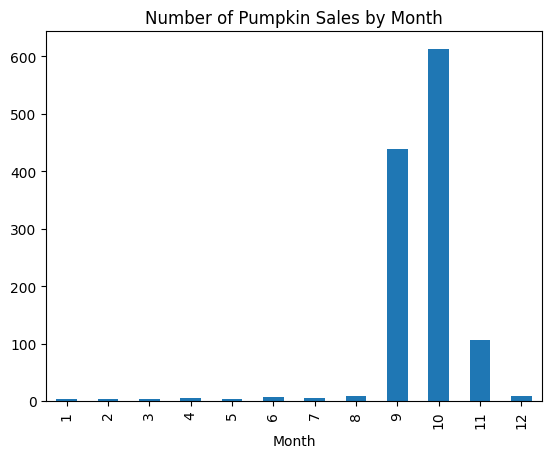

In [164]:
df_pumpkins.groupby('Month')['Avg Price'].count().plot(kind='bar', title='Number of Pumpkin Sales by Month')

[Text(0.5, 1.0, 'Average Unit Prices by Month (24/36 inch bins)')]

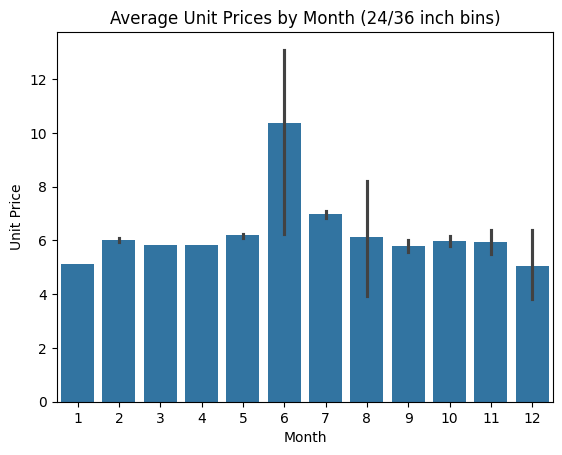

In [165]:
plot = sns.barplot(x='Month', y='Unit Price', data=df_pumpkins, estimator='mean')
plot.set(title='Average Unit Prices by Month (24/36 inch bins)')

[Text(0.5, 1.0, 'Average Prices by Month')]

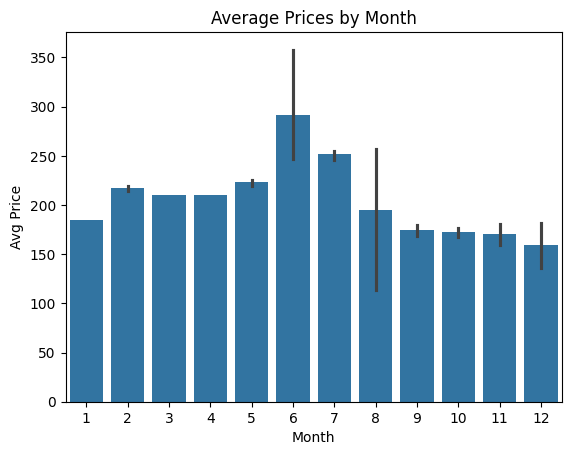

In [166]:
plot = sns.barplot(x='Month', y='Avg Price', data=df_pumpkins, estimator='mean')
plot.set(title='Average Prices by Month')

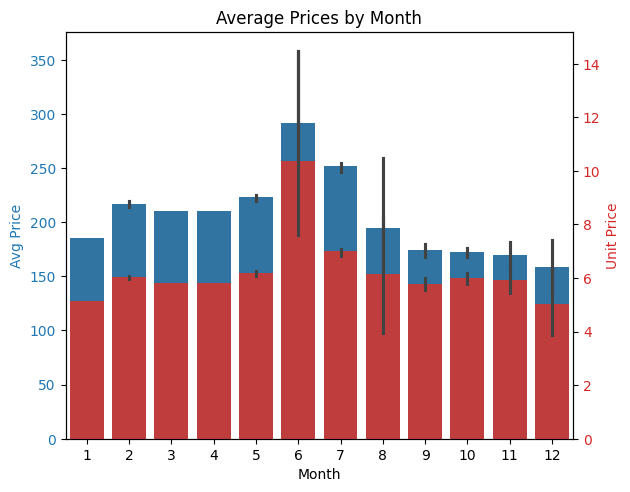

In [167]:
# overlay Avg Price and Unit Price by Month bar plots
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Price', color=color)
sns.barplot(x='Month', y='Avg Price', data=df_pumpkins, estimator='mean', ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Unit Price', color=color)  # we already handled the x-label with ax1
sns.barplot(x='Month', y='Unit Price', data=df_pumpkins, estimator='mean', ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Average Prices by Month')
plt.show()

Text(0.5, 1.0, 'Average Unit Price per Month (Line Plot)')

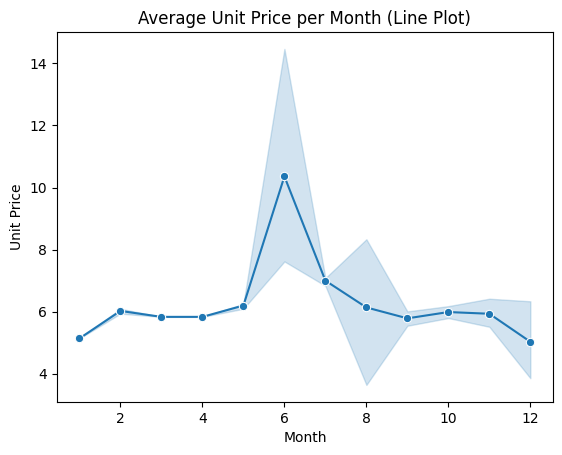

In [168]:
#lineplot
plot = sns.lineplot(x='Month', y='Unit Price', data=df_pumpkins, estimator='mean', marker='o')
plot.set_title('Average Unit Price per Month (Line Plot)')

Text(0.5, 1.0, 'Unit Prices per Month')

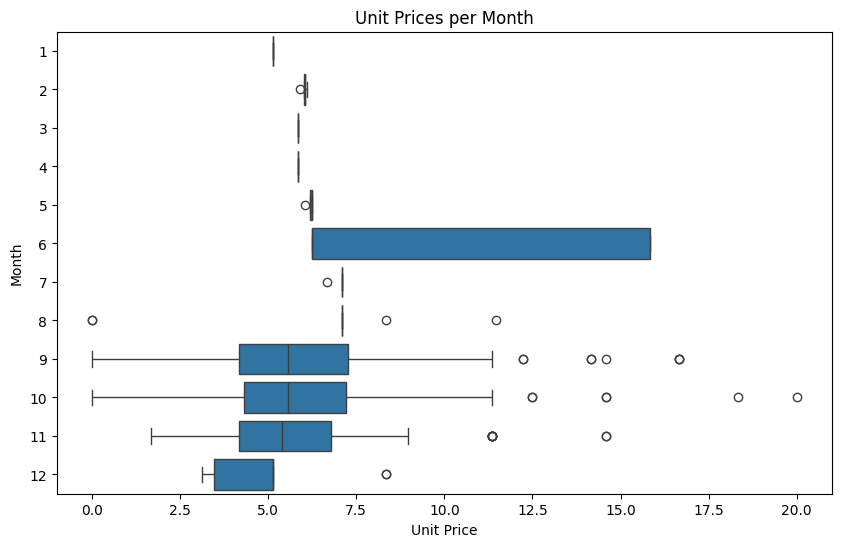

In [169]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Unit Price', y='Month', data=df_pumpkins, orient='h')
plt.title('Unit Prices per Month')

> I grafici a violino vengono utilizzati quando si desidera osservare la distribuzione dei dati numerici, e sono particolarmente utili quando si vuole fare un confronto delle distribuzioni tra più gruppi. 

> I picchi, le valli e le code di ciascuna curva di densità del gruppo possono essere confrontati per vedere dove i gruppi sono simili o diversi. 

> Elementi aggiuntivi, come i quartili dei box plot, vengono spesso aggiunti a un grafico a violino per fornire ulteriori modi di confrontare i gruppi.

Text(0.5, 1.0, 'Unit Prices per Month')

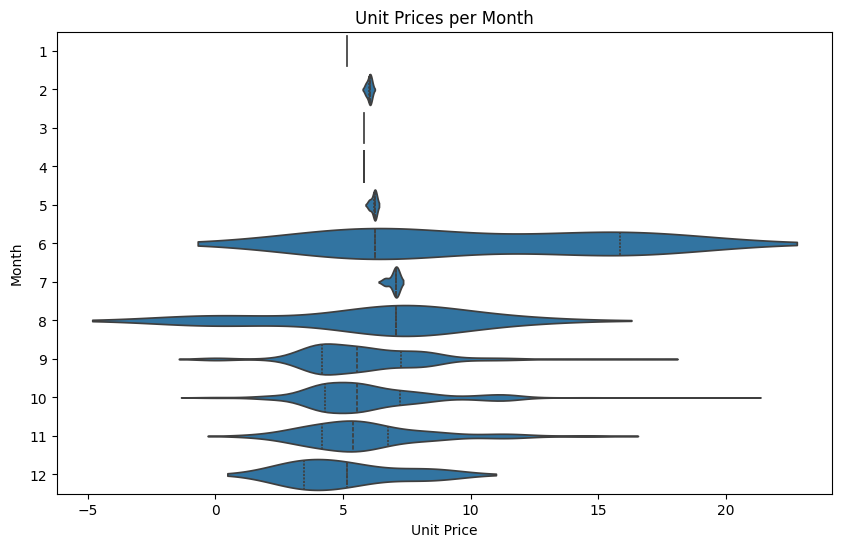

In [170]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Unit Price', y='Month', data=df_pumpkins, orient='h', density_norm='width', inner='quartile')
plt.title('Unit Prices per Month')

Text(0.5, 1.0, 'Avg Price vs Month colored by Variety')

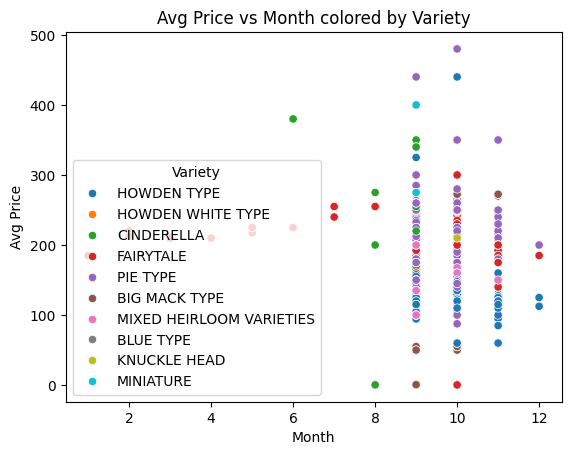

In [171]:
# scatter of Avg Price vs Month, colored by Variety

plot = sns.scatterplot(x='Month', y='Avg Price', hue='Variety', data=df_pumpkins)
plot.set_title('Avg Price vs Month colored by Variety')

Text(0.5, 1.0, 'Avg Price vs Month colored by Variety')

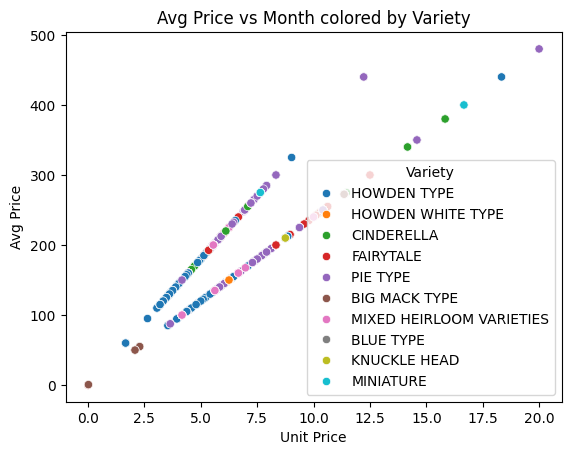

In [172]:
# scatter of Avg Price vs Unit Price, colored by Variety
plot = sns.scatterplot(x='Unit Price', y='Avg Price', hue='Variety', data=df_pumpkins)
plot.set_title('Avg Price vs Month colored by Variety')

questo grafico non serve a nulla - di fatto è giusto perché abbiamo fatto esattamente un calcolo che collega Unit Price e Avg Price

In [173]:
# forse la varietà di zucca influisce sul prezzo?
df_pumpkins['Variety'].astype('category').cat.codes.corr(df_pumpkins['Avg Price'])

np.float64(0.2322640979248408)

In [174]:
df_pumpkins['Variety'].astype('category').cat.codes.corr(df_pumpkins['Unit Price'])

np.float64(0.20987727665930844)

## Modelli ML

### LinearRegression

In [200]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [201]:
X = df_pumpkins[['Month', 'Variety', 'High Price', 'Low Price']]
y = df_pumpkins['Avg Price']

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [203]:
#One-Hot Encoding per la colonna Package
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

encoder = OneHotEncoder(sparse_output=False)

transformer = ColumnTransformer(
    transformers=[
        # nome, trasformazione, colonne
        ('variety_encoder', encoder, ['Variety'])
    ],
    remainder='passthrough'  # keep other columns unchanged
)

pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('transformer', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('variety_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [204]:
y_pred = pipeline.predict(X_test)
pipeline.score(X_test, y_test)

1.0

In [205]:
#mean absolute error
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

4.122999003732698e-14

In [206]:
#metrics
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse, r2

(2.862135406079126e-27, 1.0)

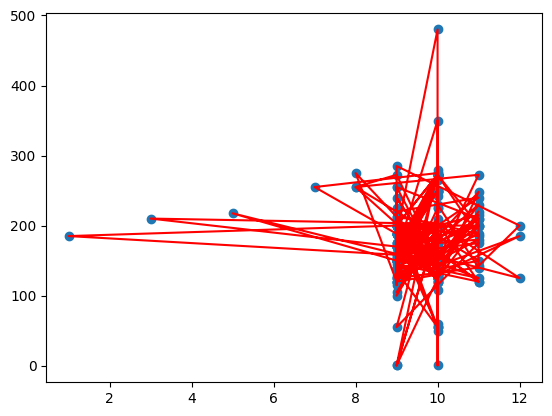

In [209]:
from matplotlib import pyplot as plt
plt.scatter(X_test['Month'], y_test)
plt.plot(X_test['Month'], y_pred, color='red')

è evidente che qualcosa non ha funzionato nel modello.

Dovremmo rivedere i dati che usiamo. Ad esempio considerare il giorno dell'anno anziché il mese

il nostro modello non saprà interpretare i dati che gli potremmo fornire in futuro.